In [29]:
import os
import duckdb
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

In [10]:
load_dotenv(dotenv_path="../.env")
minio_user = os.getenv("MINIO_ROOT_USER", "minioadmin")
minio_password = os.getenv("MINIO_ROOT_PASSWORD", "minioadmin")

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"""
    CREATE SECRET IF NOT EXISTS (
        TYPE S3,
        KEY_ID '{minio_user}',
        SECRET '{minio_password}',
        ENDPOINT 'localhost:9000',
        URL_STYLE 'path',
        USE_SSL false
    );
""")

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Financial Predictive Models vers2")

print(" Connected to DuckDB Data Lake and MLflow Dashboard successfully.")


 Connected to DuckDB Data Lake and MLflow Dashboard successfully.


In [11]:
print("Loading Data Lake into memory...")
df = con.execute("SELECT * FROM read_parquet('s3://analytics-data/ml_features.parquet')").df()

print("Loading Quality Assurance metrics...")
stats_df = con.execute("SELECT * FROM read_parquet('s3://analytics-data/feature_statistics.parquet')").df()

best_features_df = stats_df[stats_df['quality_flag'] == 'PASS'].nlargest(15, 'importance_score')
ml_features_list = best_features_df['feature_name'].tolist()

print("\n--- DATA LOADED ---")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Top 15 ML Features: {', '.join(ml_features_list)}")


Loading Data Lake into memory...


Loading Quality Assurance metrics...

--- DATA LOADED ---
Total Rows: 514,971
Top 15 ML Features: hl_ratio, close_position, bb_percentage, stoch_k, roc_10, roc_20, bb_width, stoch_d, rsi_14, volume_ratio, obv, macd_histogram, volume, prev_volume, macd


In [14]:
def prepare_asset_data(df, symbol, timeframe, features, test_start_date):
    """
    filters data, creates the correct target label, 
    and chronologically splits the data for testing.
    """
    clean_data = df[(df['asset_symbol'] == symbol) & (df['interval'] == timeframe)].copy()
    
    clean_data = clean_data.sort_values('date')
    
    clean_data['future_close'] = clean_data['close'].shift(-1)
    clean_data = clean_data.dropna(subset=features + ['future_close'])
    
    clean_data['target'] = np.where(clean_data['future_close'] > clean_data['close'], 1, 0)
    
    clean_data.set_index('date', inplace=True)
    
    if len(clean_data) < 100:
        print(f"Warning: Not enough data for {symbol} on {timeframe}.")
        return None, None, None, None
    
    train_data = clean_data[clean_data.index < test_start_date]
    test_data = clean_data[clean_data.index >= test_start_date]
    
    print(f"Data Split for {symbol} [{timeframe}]:")
    print(f"  Training Rows: {len(train_data)}")
    print(f"  Testing Rows:  {len(test_data)}\n")
    
    X_train = train_data[features]
    y_train = train_data['target']
    
    X_test = test_data[features]
    y_test = test_data['target']
    
    return X_train, X_test, y_train, y_test


def train_and_track_model(model, X_train, X_test, y_train, y_test, run_name):
    """Trains algorithm, logs to MLflow, and outputs a Superset-ready DataFrame."""
    print(f"Tracking experiment '{run_name}' to MLflow...")
    
    with mlflow.start_run(run_name=run_name):
        mlflow.autolog() 
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        print(f" Model Trained! Accuracy: {accuracy * 100:.2f}%")
        
        results_df = pd.DataFrame(index=X_test.index)
        results_df['actual_direction'] = y_test
        results_df['predicted_direction'] = y_pred
        
        results_df.reset_index(inplace=True)
        
    return model, results_df


In [20]:
symbol = '1000PEPE'
timeframe = '1h'
asset_data = df[(df['asset_symbol'] == symbol) & (df['interval'] == timeframe)]
start_date = asset_data['date'].min()
end_date = asset_data['date'].max()
split_idx = int(len(asset_data) * 0.8)
auto_test_start = asset_data.sort_values('date').iloc[split_idx]['date']
print(f" Setup for {symbol} [{timeframe}]")
print(f" Data runs from {start_date} to {end_date}")
print(f" Training on data BEFORE: {auto_test_start}")
print(f" Testing on unseen data AFTER: {auto_test_start}\n")

 Setup for 1000PEPE [1h]
 Data runs from 2023-05-11 18:00:00 to 2026-03-14 18:00:00
 Training on data BEFORE: 2025-08-19 04:00:00
 Testing on unseen data AFTER: 2025-08-19 04:00:00



In [21]:
X_train, X_test, y_train, y_test = prepare_asset_data(
    df=df, symbol=symbol, timeframe=timeframe, 
    features=ml_features_list, test_start_date=auto_test_start
)
if X_train is not None:
    my_algorithm = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
    run_name = f"{symbol}_{timeframe}_RandomForest"
    
    trained_model, results_df = train_and_track_model(
        model=my_algorithm, X_train=X_train, X_test=X_test, 
        y_train=y_train, y_test=y_test, run_name=run_name
    )

Data Split for 1000PEPE [1h]:
  Training Rows: 19930
  Testing Rows:  4982

Tracking experiment '1000PEPE_1h_RandomForest' to MLflow...


2026/03/14 19:42:22 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/03/14 19:42:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


 Model Trained! Accuracy: 50.98%
🏃 View run 1000PEPE_1h_RandomForest at: http://localhost:5000/#/experiments/3/runs/abf6e00ce51147deb92154ff18e70ba1
🧪 View experiment at: http://localhost:5000/#/experiments/3


<Figure size 600x500 with 0 Axes>

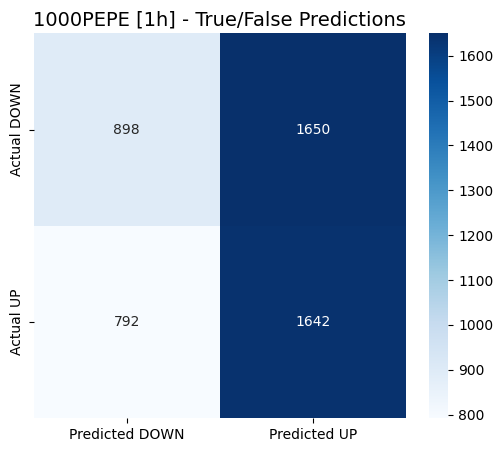

In [31]:
cm = confusion_matrix(results_df['actual_direction'], results_df['predicted_direction'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted DOWN', 'Predicted UP'], 
            yticklabels=['Actual DOWN', 'Actual UP'])
plt.title(f"{symbol} [{timeframe}] - True/False Predictions", fontsize=14)
plt.show()